In [17]:

import os
import numpy as np
import matplotlib.pyplot as plt
#neuer_pfad = r"C:\Daten\Studium\5. Semester\Fortgeschrittenen-Praktikum\Raman\Auswertung\Grünewald Probe\Grünewald Probe - auf Kreuz"

neuer_pfad = "/Users/trinity/Desktop"

os.chdir(neuer_pfad)

In [18]:
 #Moderne, aber wissenschaftlich saubere Einstellungen
plt.rcParams.update({
    # Moderne, saubere Schrift (ohne Schnörkel)
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    
    # Ticks zeigen nach außen und nur unten/links (viel offener)
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
    
    # Dezentes Gitter
    "axes.grid": True,
    "grid.color": "#7F8C8D",
    "grid.linestyle": ":",        # Gepunktet statt gestrichelt wirkt feiner
    "grid.alpha": 0.5,
    
    # Legende ohne Rahmen
    "legend.frameon": True,
    
    # Hohe Auflösung
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

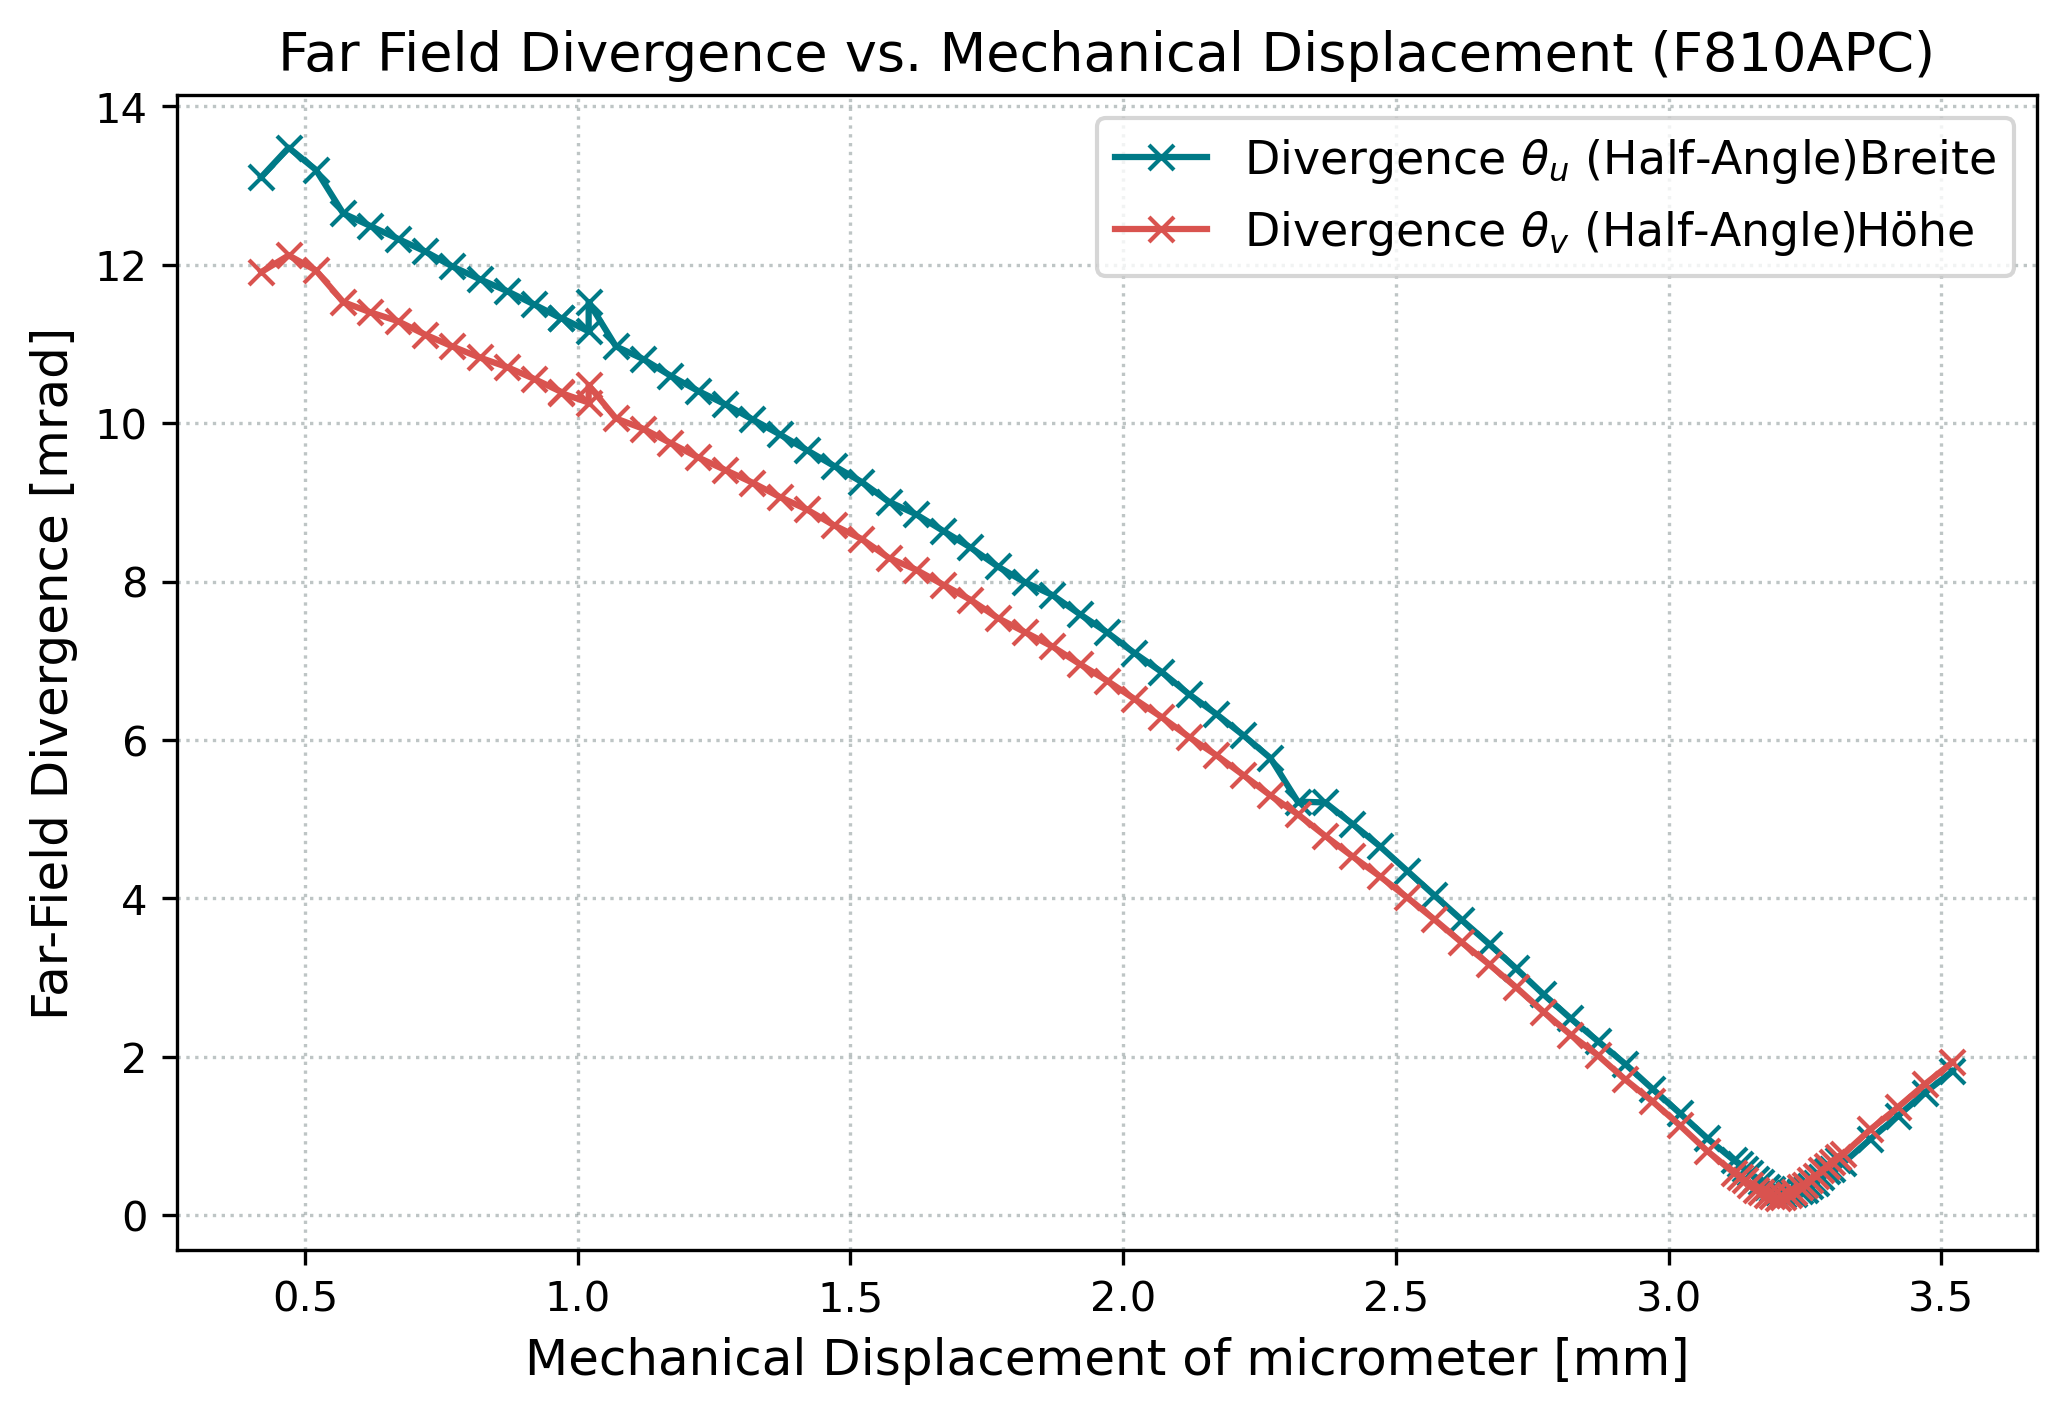

In [ ]:
#plot theta
data = np.genfromtxt(
    '/Users/trinity/Desktop/bachelor.thesis/measurements/1308_1408_measure/m2_measurements_1308.csv',
    delimiter=','
)

distance_mechanical = data[:, 0]
theta_u = data[:, 1]
M2_u = data[:, 2]
zR_u = data[:, 3]
theta_v = data[:, 4]
M2_v = data[:, 5]
zR_v = data[:, 6]
realabstand = data[:, 7]
# Plot erstellen
plt.figure(figsize=(8, 5))
plt.plot(realabstand, theta_u, '-x', label=r'Divergence $\theta_u$ (Half-Angle)Breite', color='#007A87')
plt.plot(realabstand, theta_v, '-x', label=r'Divergence $\theta_v$ (Half-Angle)Höhe', color='#D9534F')

# Achsenbeschriftungen machen das Labor-Leben leichter
plt.xlabel(r"Mechanical Displacement of micrometer [mm] Messung")
plt.ylabel(r"Far-Field Divergence [mrad]")
plt.title('Far Field Divergence vs. Mechanical Displacement (F810APC)')
plt.legend()
#plt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/measurements/setup/divergence_vs_mechanival_displacement.pdf")

plt.show()
#theta= M2 wave/ w*pi


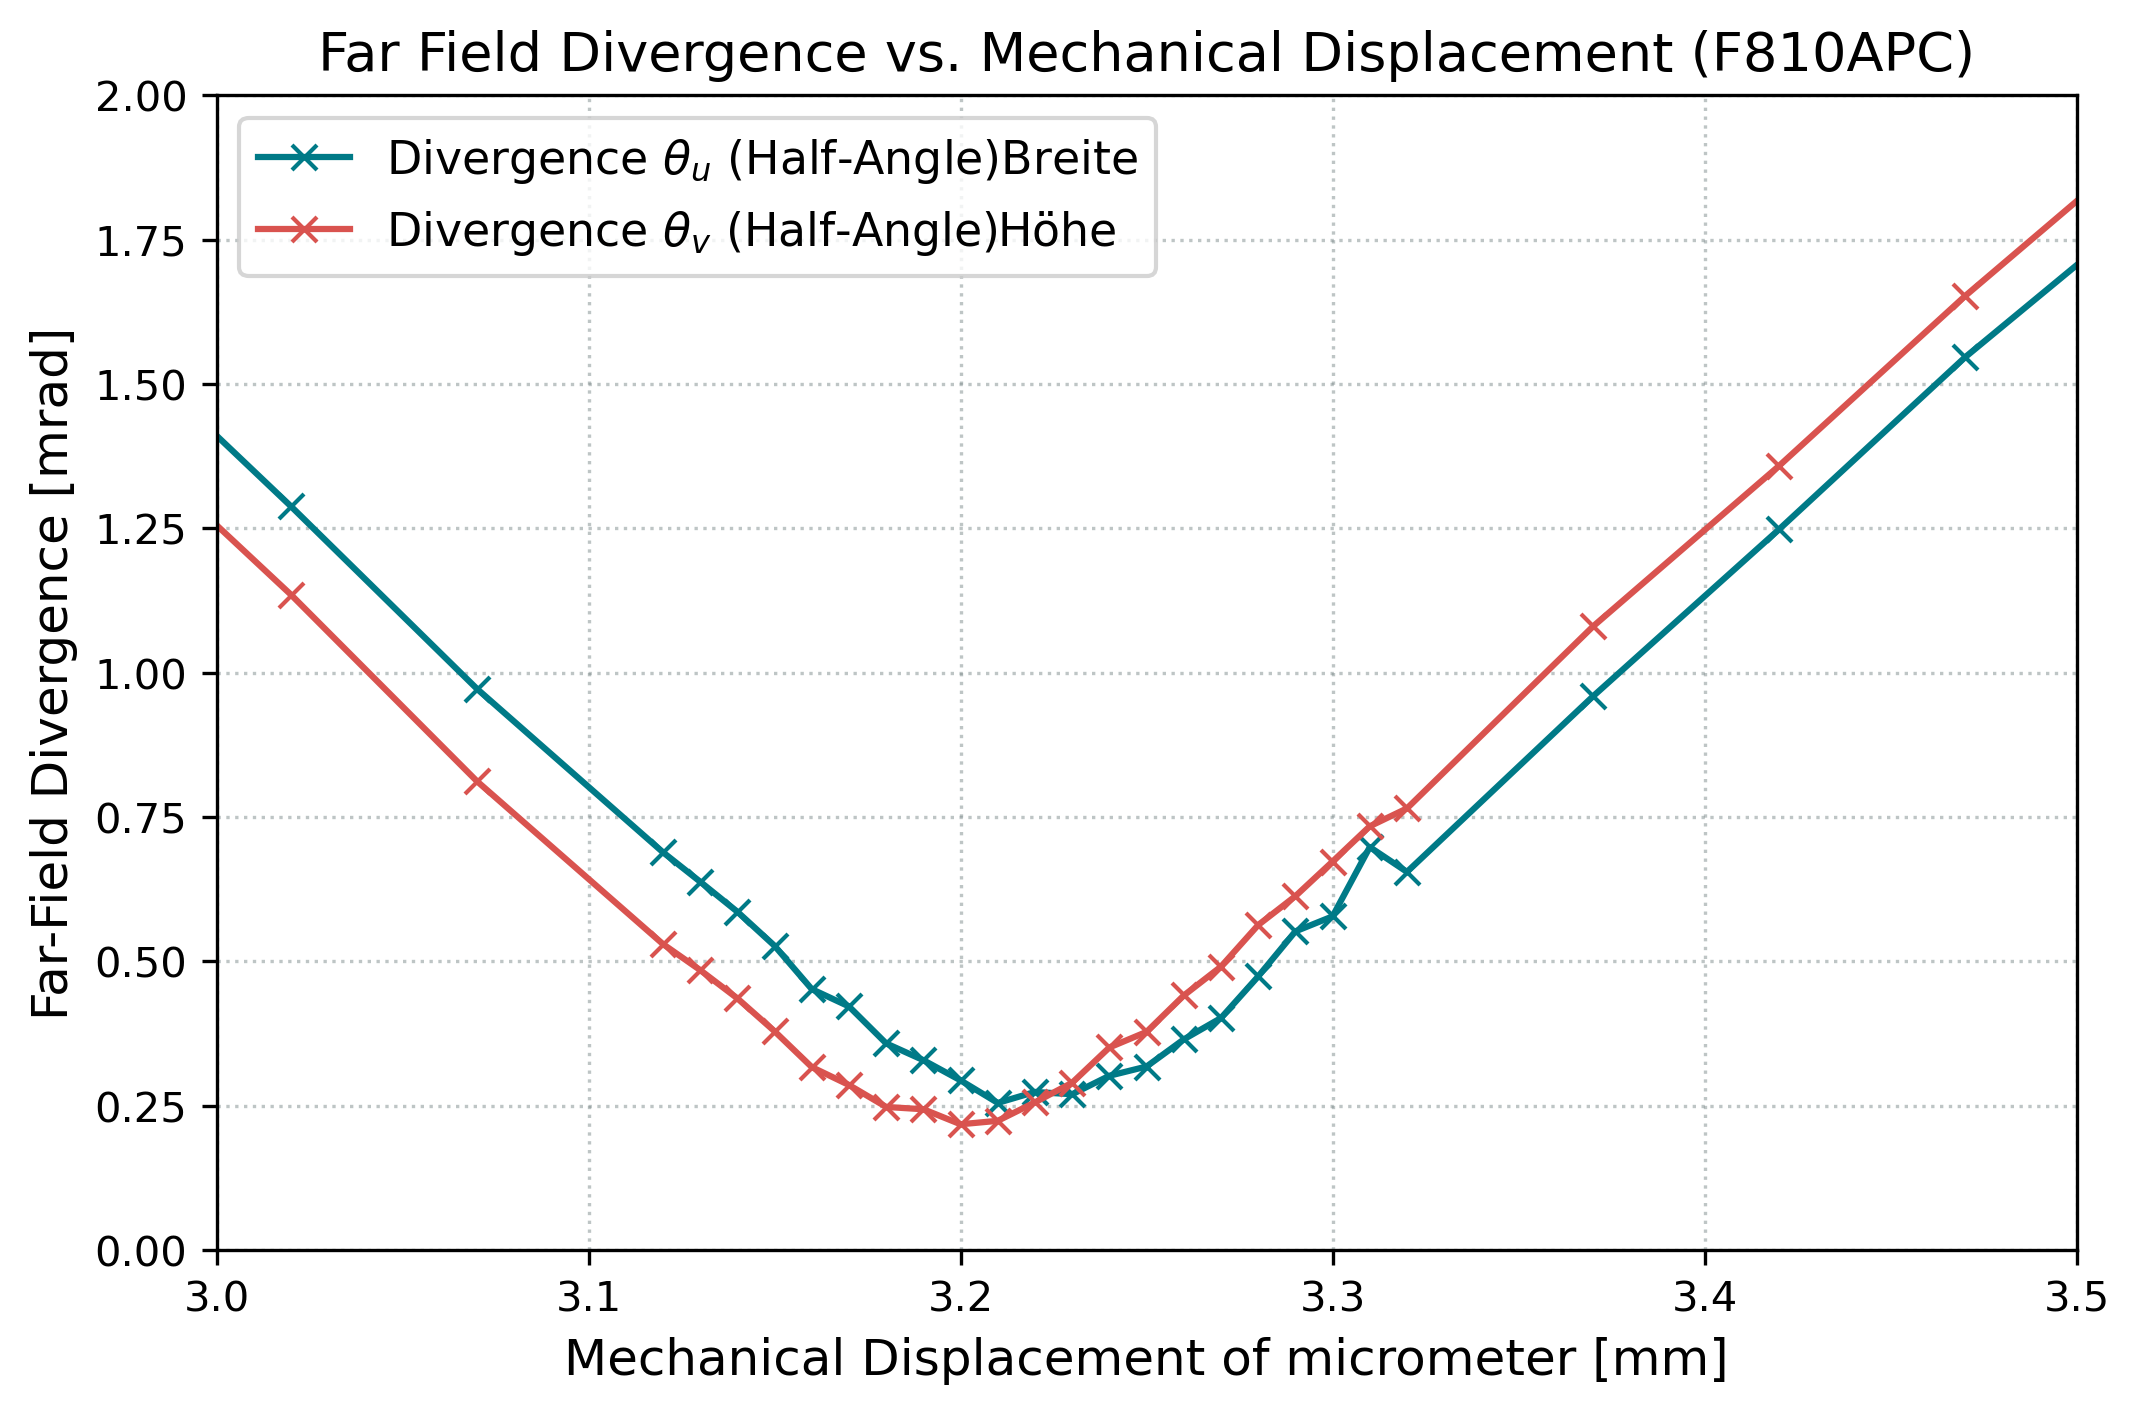

In [20]:
#plot theta
data = np.genfromtxt(
    '/Users/trinity/Desktop/bachelor.thesis/measurements/1308_1408_measure/m2_measurements_1308.csv',
    delimiter=','
)

distance_mechanical = data[:, 0]
theta_u = data[:, 1]
M2_u = data[:, 2]
zR_u = data[:, 3]
theta_v = data[:, 4]
M2_v = data[:, 5]
zR_v = data[:, 6]
realabstand = data[:, 7]
# Plot erstellen
plt.figure(figsize=(8, 5))
plt.plot(realabstand, theta_u, '-x', label=r'Divergence $\theta_u$ (Half-Angle)Breite', color='#007A87')
plt.plot(realabstand, theta_v, '-x', label=r'Divergence $\theta_v$ (Half-Angle)Höhe', color='#D9534F')

# Achsenbeschriftungen machen das Labor-Leben leichter
plt.xlabel(r"Mechanical Displacement of micrometer [mm]")
plt.ylim(0, 2)
plt.xlim(3, 3.5)
plt.ylabel(r"Far-Field Divergence [mrad]")
plt.title('Far Field Divergence vs. Mechanical Displacement (F810APC)')
plt.legend()
#plt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/measurements/setup/divergence_vs_mechanival_displacement.pdf")

plt.show()
#theta= M2 wave/ w*pi

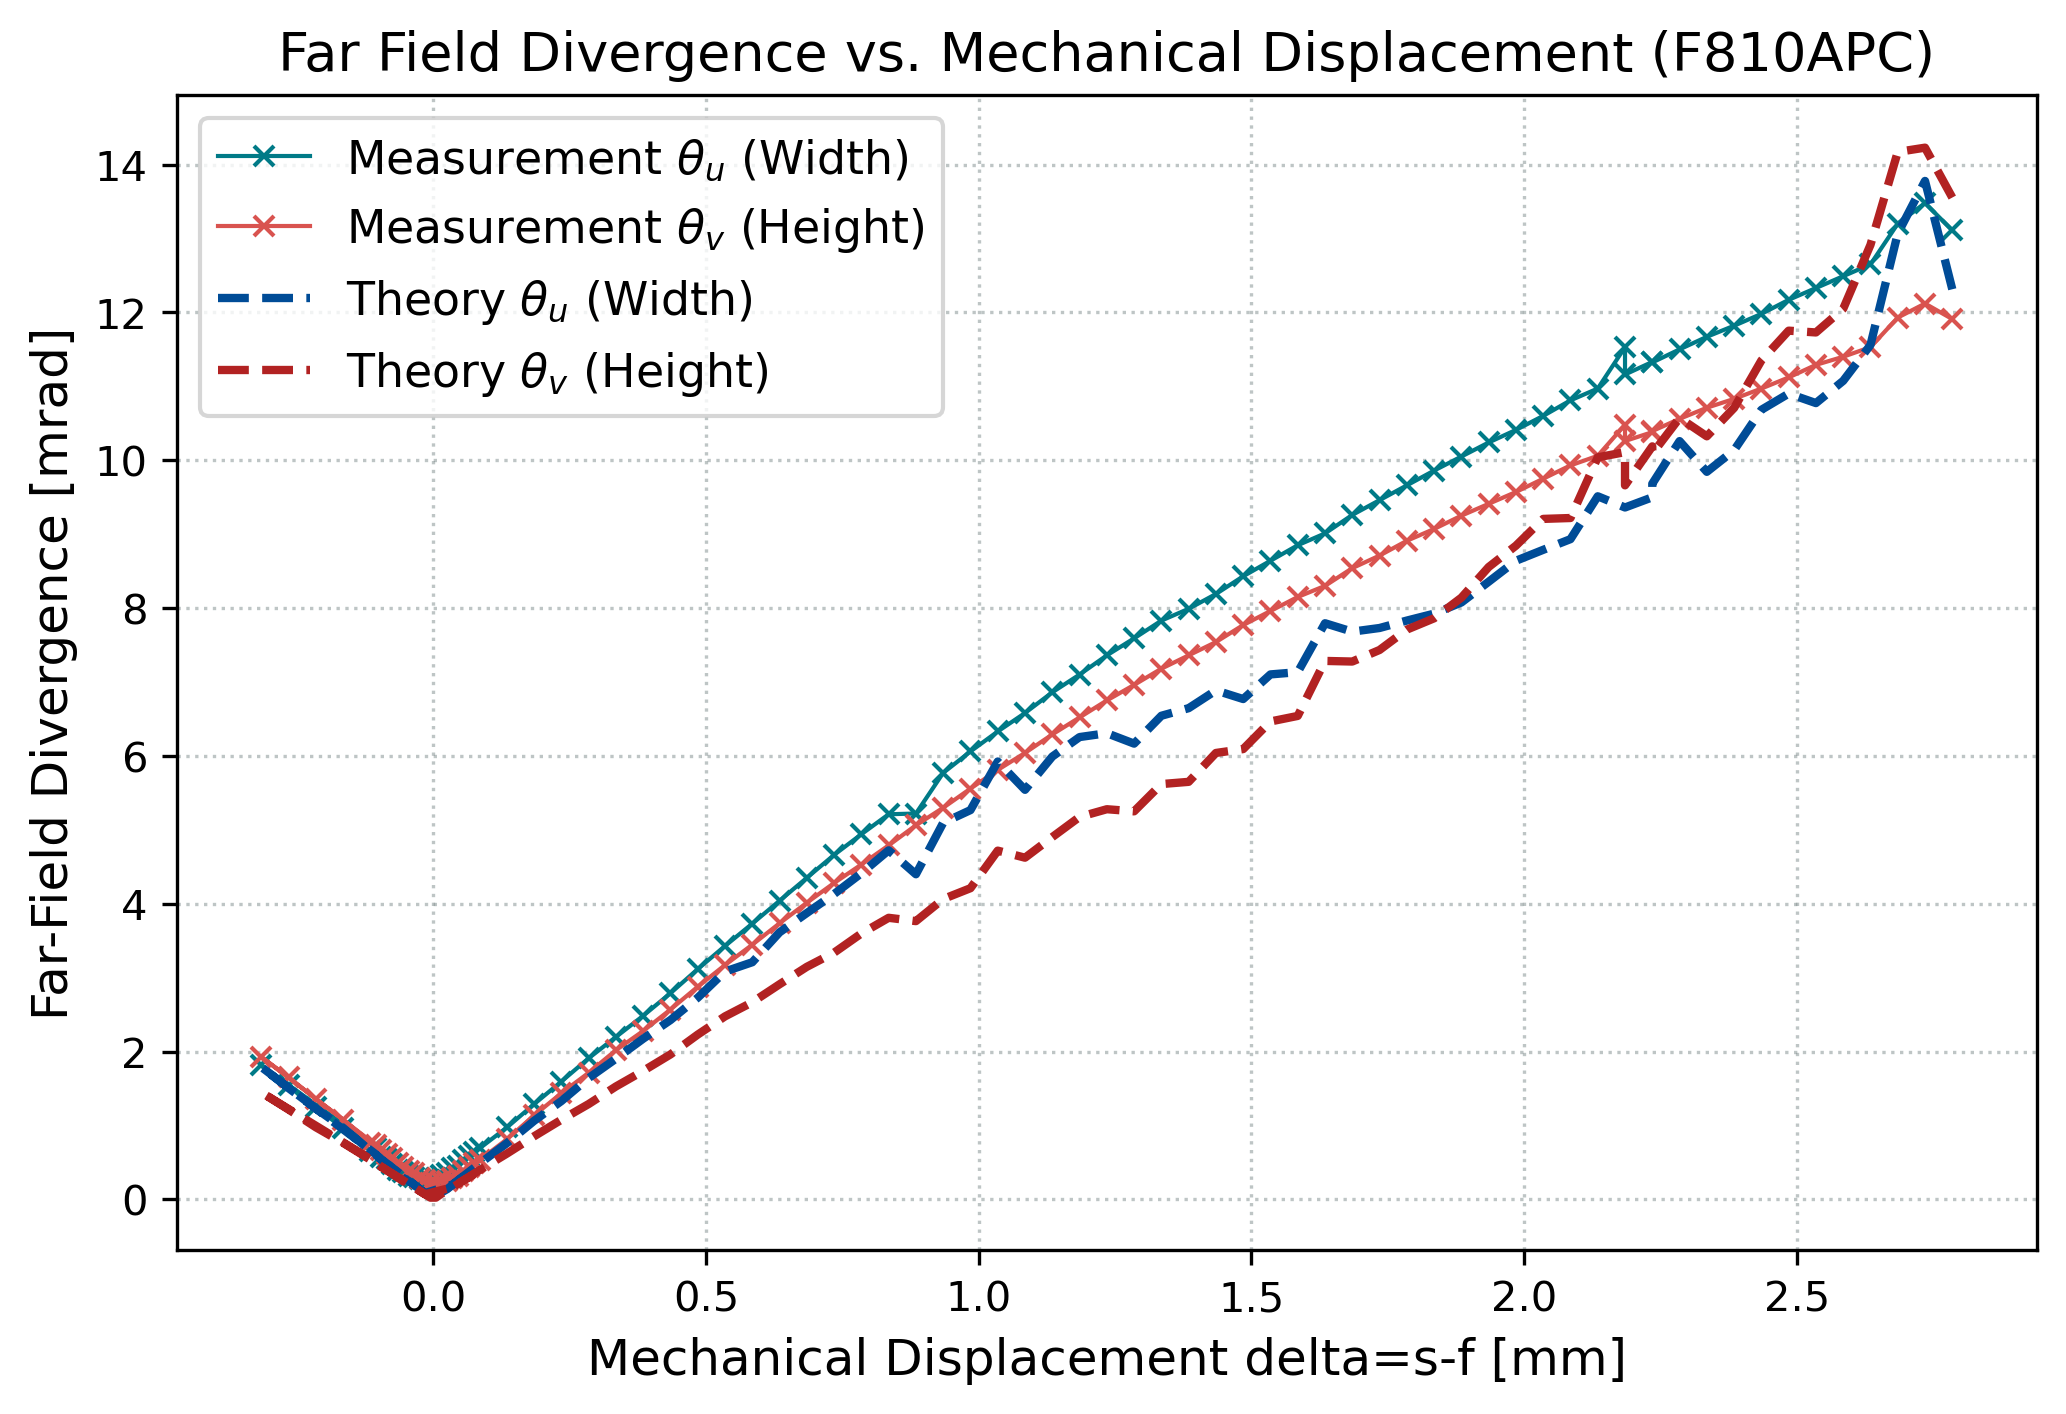

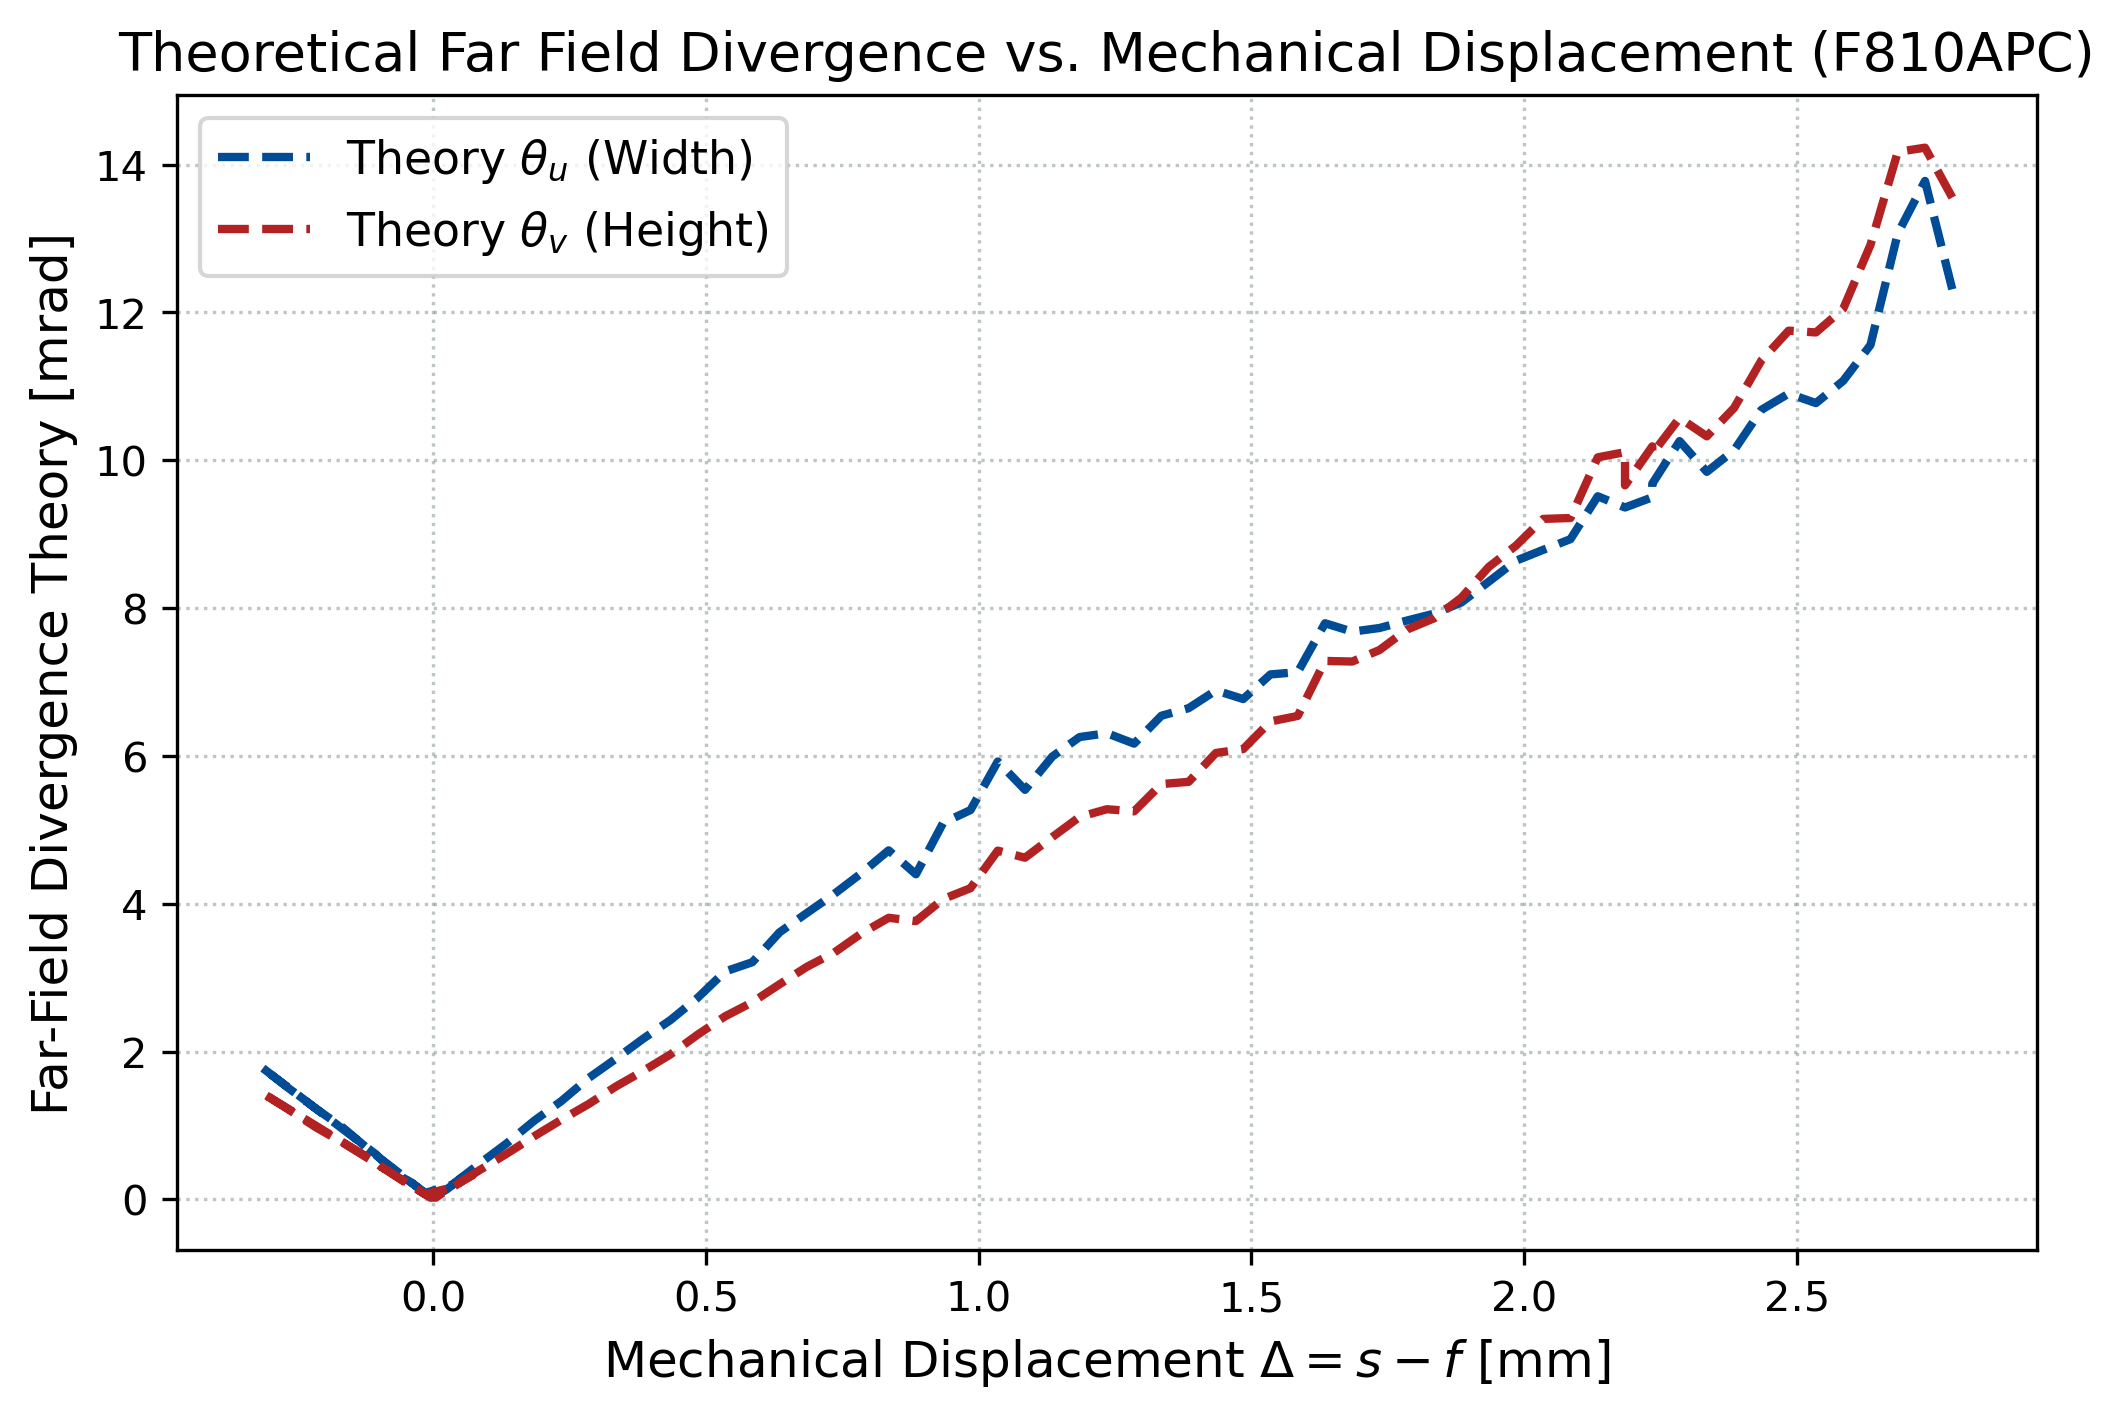

In [28]:
#plot theta mit 0=perfect kollimated
data = np.genfromtxt(
    '/Users/trinity/Desktop/bachelor.thesis/measurements/1308_1408_measure/m2_measurements_1308.csv',
    delimiter=','
)

lam  = 1064e-9   # Wavelength [m]
MFD  = 5.4e-6    # Mode Field Diameter [m]
w0   = MFD / 2   # Waist radius at the fiber end [m]
f    = 36.6e-3  

distance_mechanical = data[:, 0]
delta= distance_mechanical - 4.315
theta_u = data[:, 1]
M2_u = data[:, 2]
zR_u = data[:, 3]
theta_v = data[:, 4]
M2_v = data[:, 5]
zR_v = data[:, 6]

def theta(M2, delta):
    zR_fiber = (np.pi * w0**2) / lam*M2
    return M2*lam/(np.pi*w0*f) *np.sqrt(delta**2 + zR_fiber**2)
# Plot erstellen
plt.figure(figsize=(8, 5))
plt.plot(delta, theta_u, '-x', color='#007A87', linewidth=1, markersize=5, label=r'Measurement $\theta_u$ (Width)')
plt.plot(delta, theta_v, '-x', color='#D9534F', linewidth=1, markersize=5, label=r'Measurement $\theta_v$ (Height)')
plt.plot(delta, theta(M2_u, delta), '--', color='#004C97', linewidth=2, label=r'Theory $\theta_u$ (Width)')
plt.plot(delta, theta(M2_v, delta), '--', color='#B22222', linewidth=2, label=r'Theory $\theta_v$ (Height)')

# Achsenbeschriftungen machen das Labor-Leben leichter
plt.xlabel(r"Mechanical Displacement delta=s-f [mm]")
plt.ylabel(r"Far-Field Divergence [mrad]")
#plt.xlim(0, 0.5)
#plt.ylim(0, 2)
plt.title('Far Field Divergence vs. Mechanical Displacement (F810APC)')
plt.legend()
#plt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/measurements/setup/divergence_vs_mechanival_displacement.pdf")

plt.show()
#theta= M2 wave/ w*pi

#theory:
#theta(s-f)

plt.figure(figsize=(8, 5))

plt.plot(delta, theta(M2_u, delta), '--', color='#004C97', linewidth=2, label=r'Theory $\theta_u$ (Width)')
plt.plot(delta, theta(M2_v, delta), '--', color='#B22222', linewidth=2, label=r'Theory $\theta_v$ (Height)')


plt.xlabel(r"Mechanical Displacement $\Delta = s - f$ [mm]")
plt.ylabel(r"Far-Field Divergence Theory [mrad]")
plt.title('Theoretical Far Field Divergence vs. Mechanical Displacement (F810APC)')       
plt.legend()
plt.show() 


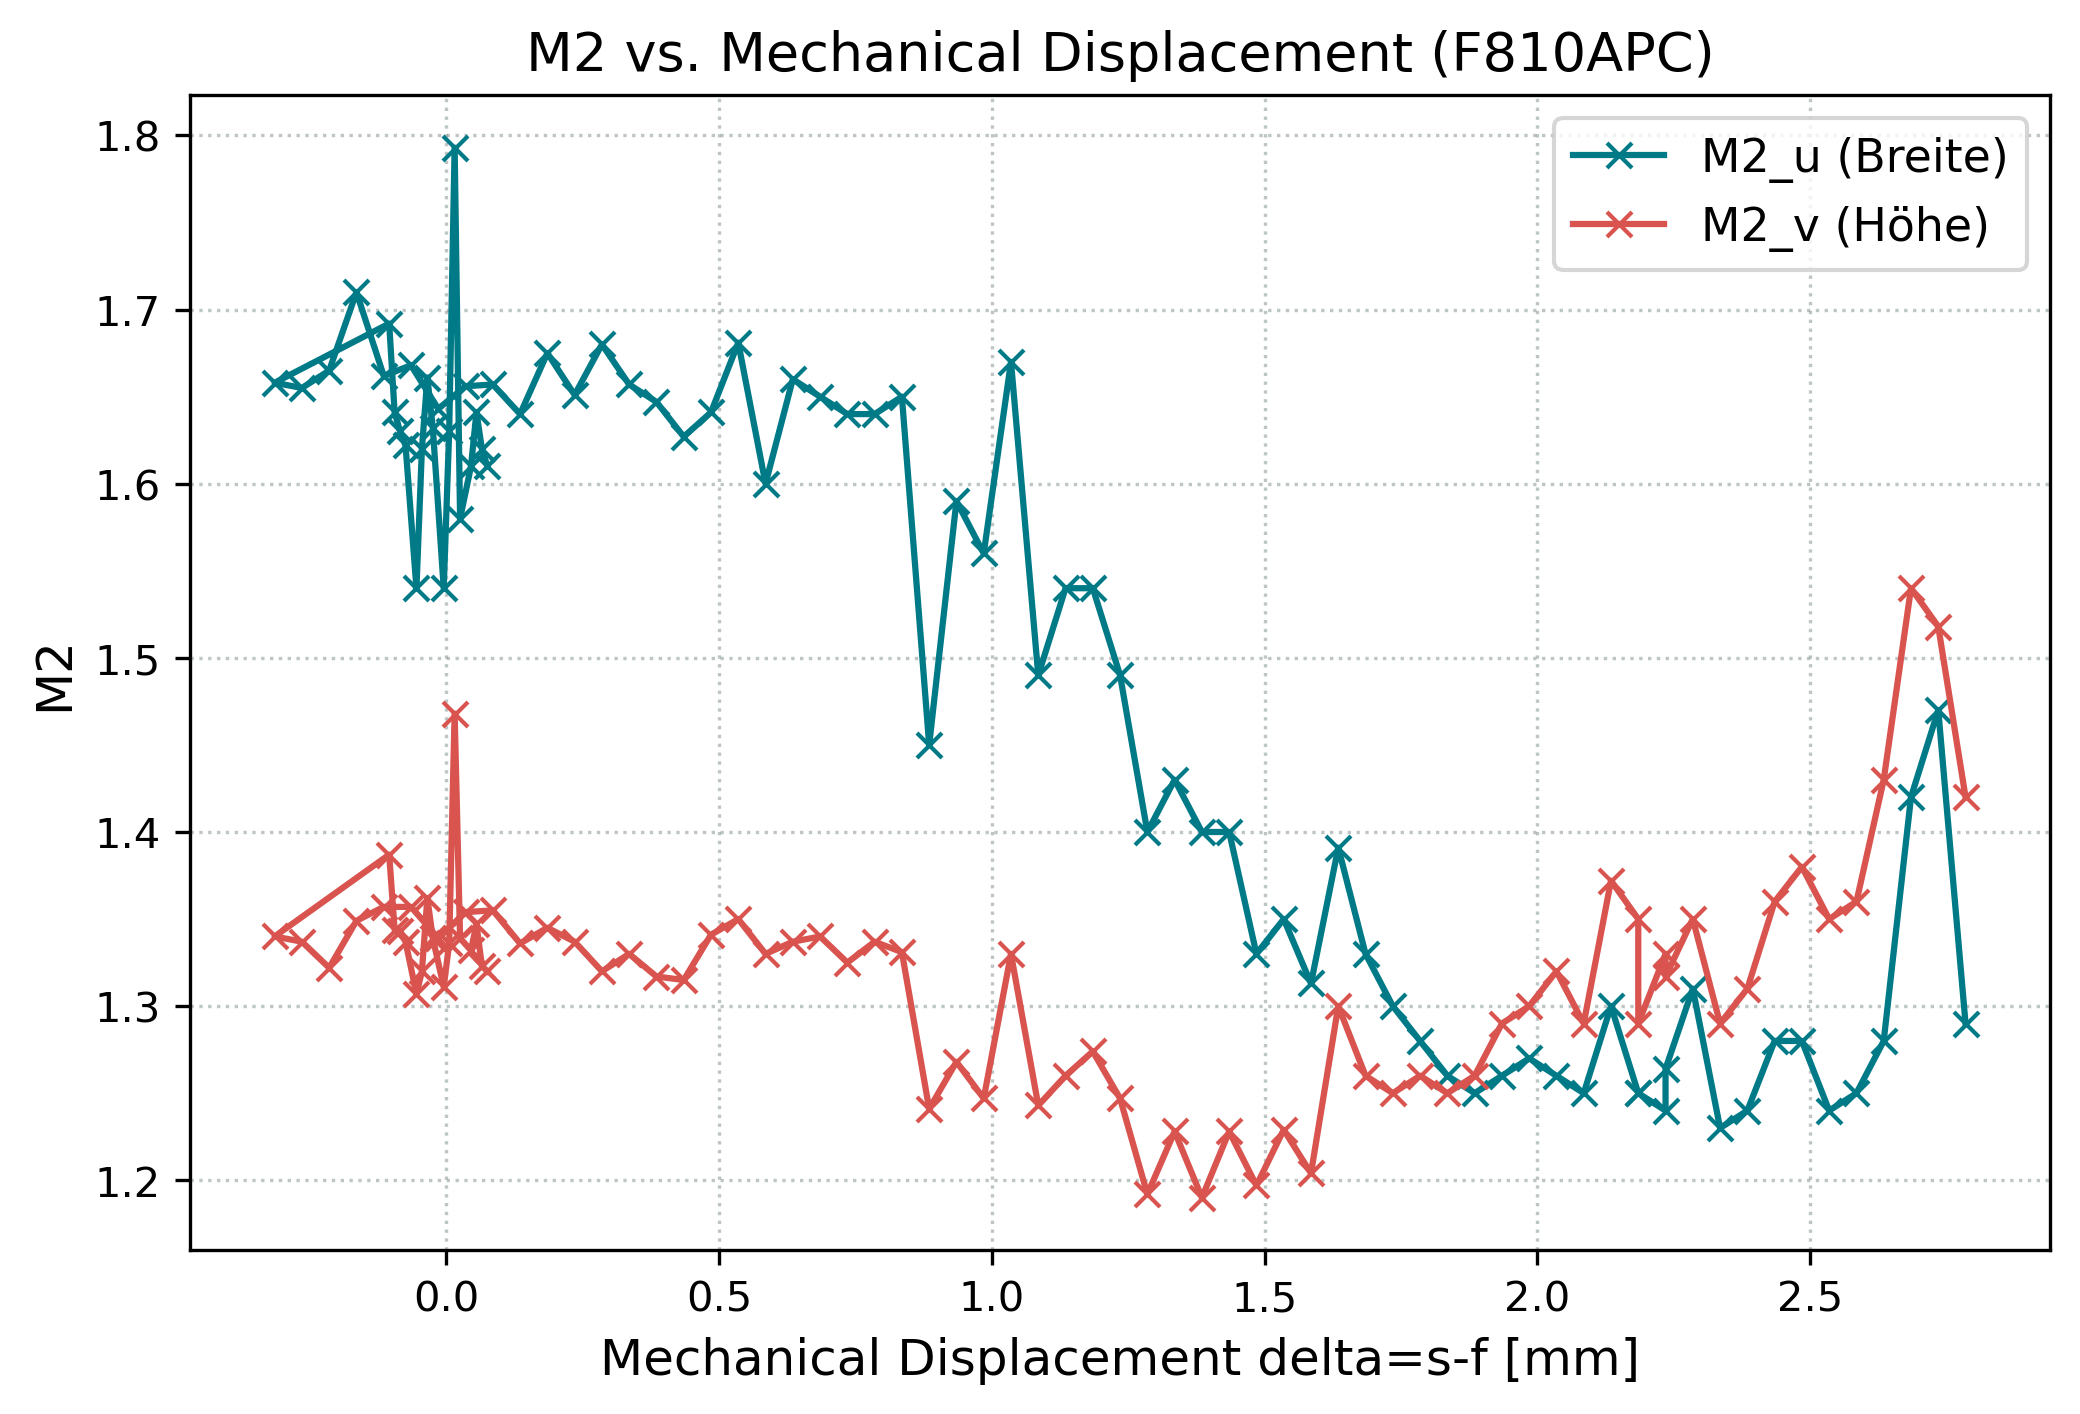

In [25]:
#m2 plot
data = np.genfromtxt(
    '/Users/trinity/Desktop/bachelor.thesis/measurements/1308_1408_measure/m2_measurements_1308.csv',
    delimiter=','
)

distance_mechanical = data[:, 0]
delta= distance_mechanical - 4.315
theta_u = data[:, 1]
M2_u = data[:, 2]
theta_v = data[:, 4]
M2_v = data[:, 5]


plt.figure(figsize=(8, 5))
plt.plot(delta, M2_u, '-x',label='M2_u (Breite)', color='#007A87')
plt.plot(delta, M2_v, '-x', label='M2_v (Höhe)', color='#D9534F')

plt.xlabel(r"Mechanical Displacement delta=s-f [mm]")
plt.ylabel('M2')
plt.title('M2 vs. Mechanical Displacement (F810APC)')
plt.legend()
plt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/measurements/setup/M2_vs_mechanival_displacement.pdf")


plt.show()
#theta= M2 wave/ w*pi


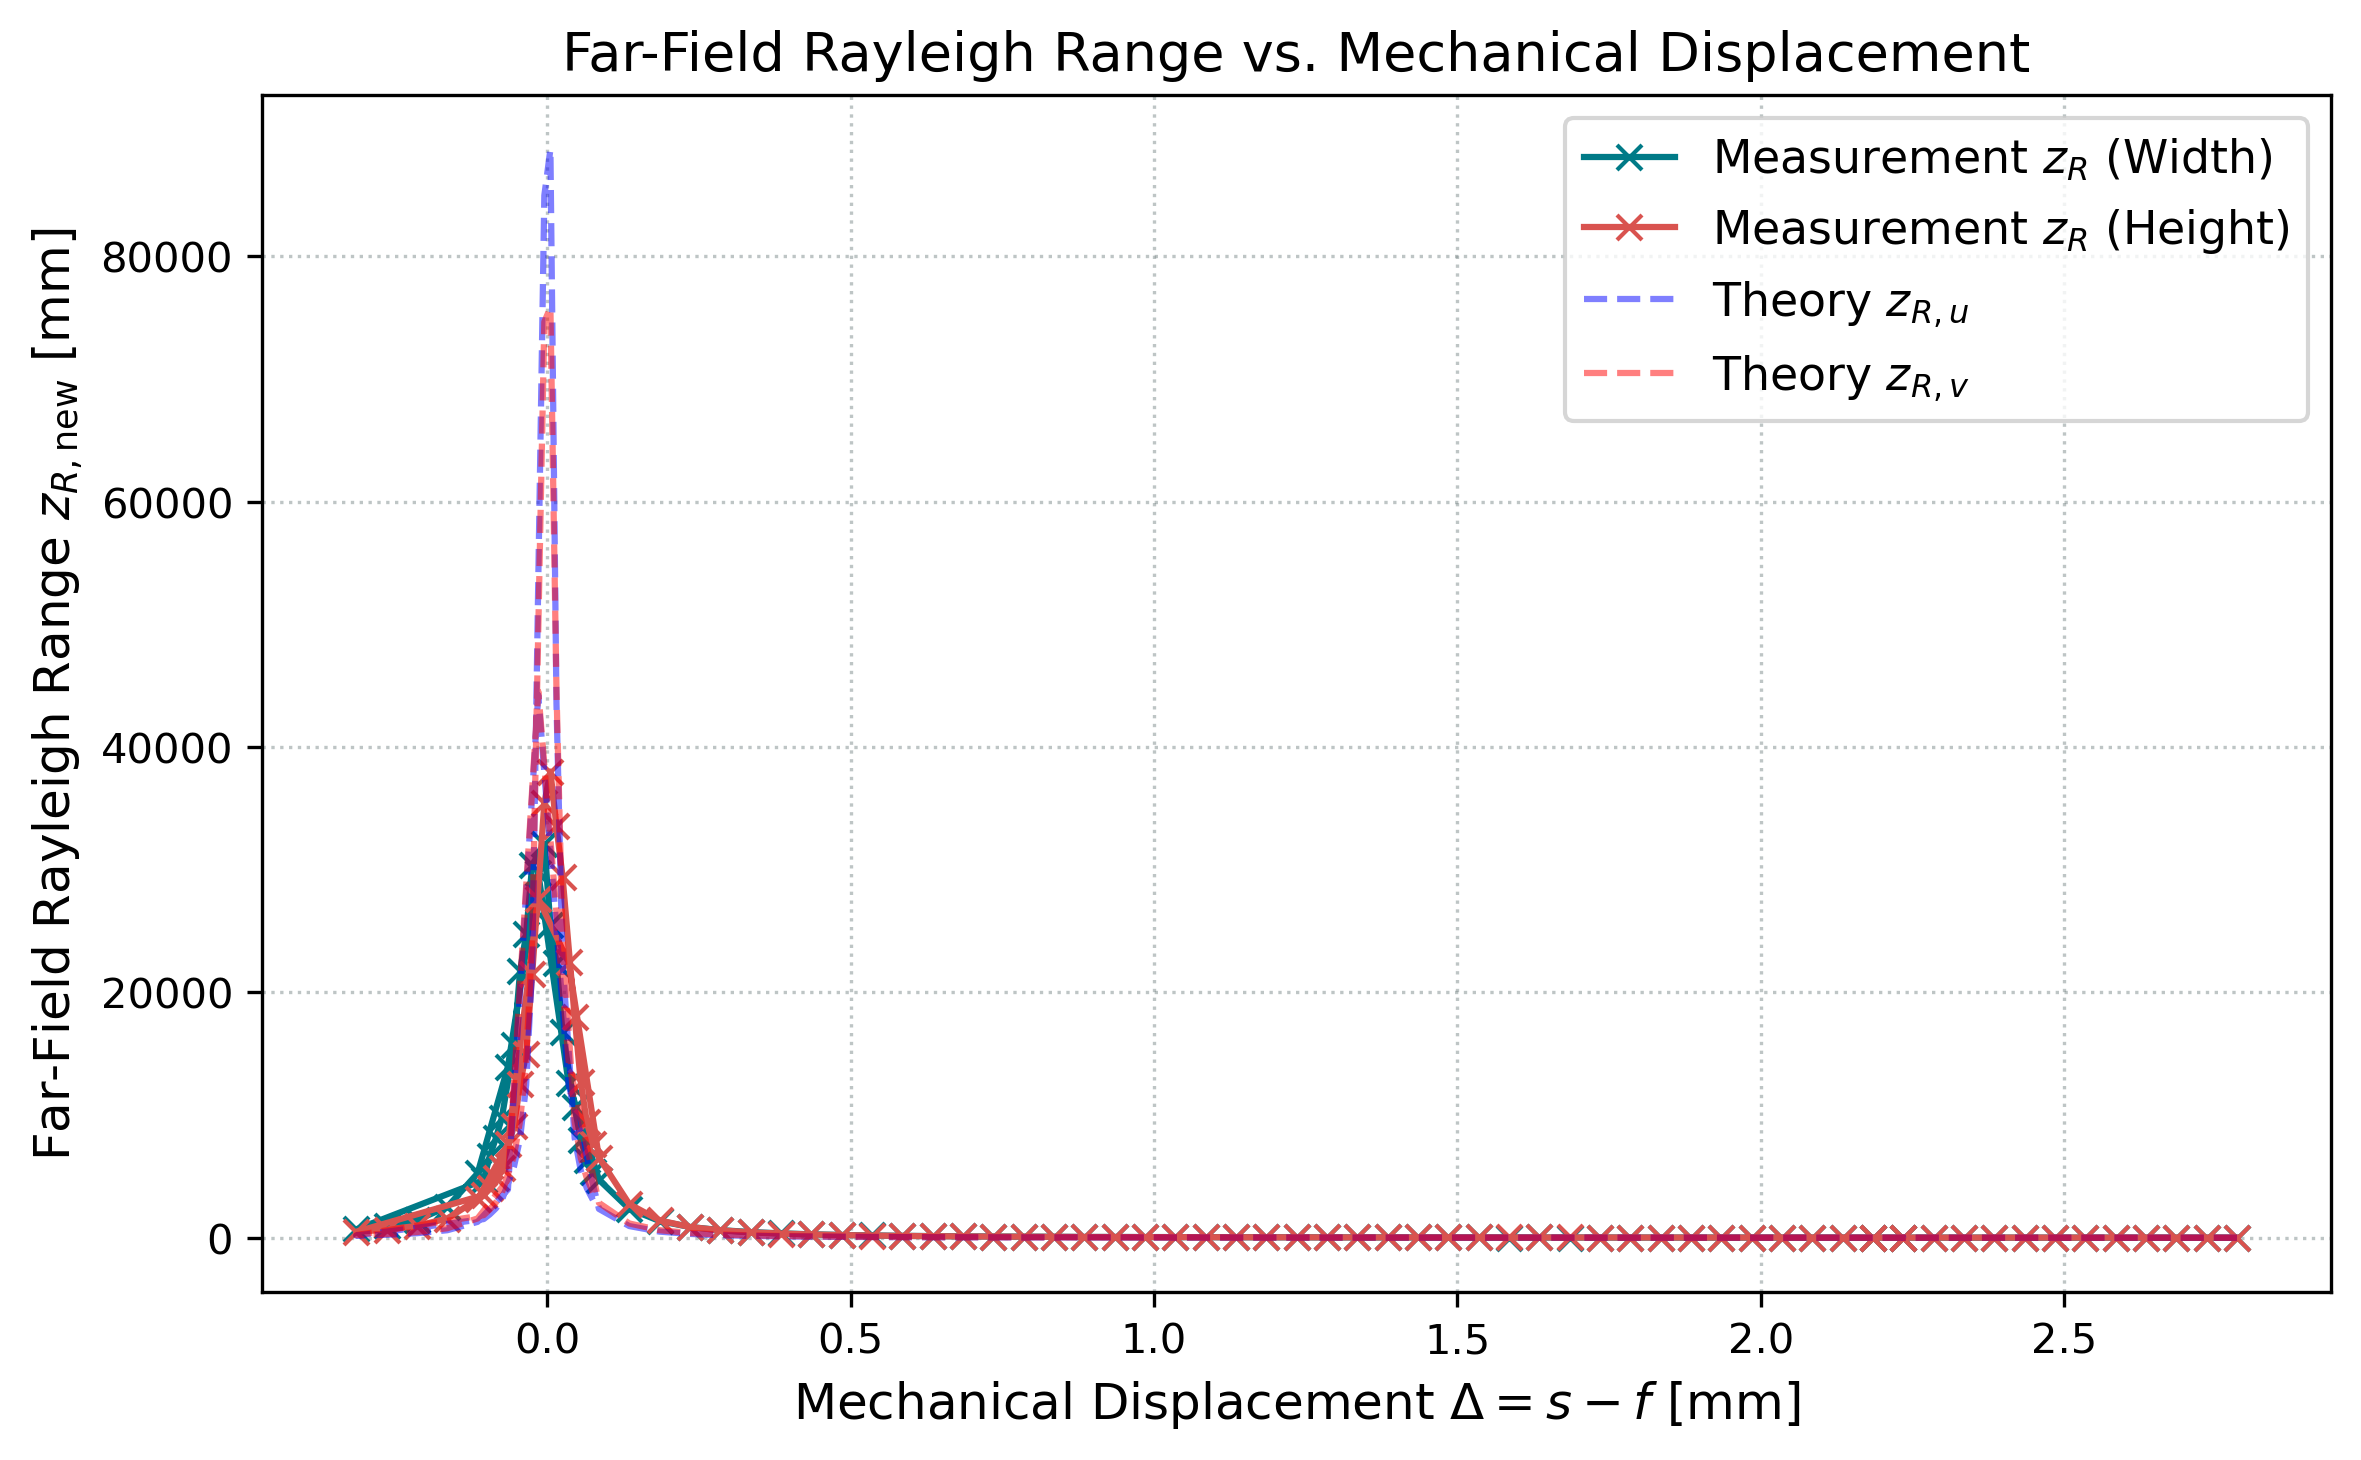

In [26]:
# ==========================================
# 1. Daten einlesen & Parameter
# ==========================================
data = np.genfromtxt(
    '/Users/trinity/Desktop/bachelor.thesis/measurements/1308_1408_measure/m2_measurements_1308.csv',
    delimiter=','
)

lam  = 1064e-9   
MFD  = 5.4e-6    
w0   = MFD / 2   
f    = 36.6e-3  

# Daten zuweisen
distance_mechanical = data[:, 0]
delta_mm = distance_mechanical - 4.315
delta_m  = delta_mm * 1e-3  # WICHTIG: Delta in Meter für die Theorie-Formel!

theta_u = data[:, 1]
M2_u    = data[:, 2]
zR_u    = data[:, 3]
theta_v = data[:, 4]
M2_v    = data[:, 5]
zR_v    = data[:, 6]

# ==========================================
# 2. Theorie-Funktion
# ==========================================
def zR_theory(delta_meters, M2_val):
    lam_eff = lam * M2_val
    zR_fiber = (np.pi * w0**2) / lam_eff  # Die Klammer-Falle ist hier behoben!
    
    # Komplett in Metern rechnen
    zR_new_meters = (f**2 * zR_fiber) / (delta_meters**2 + zR_fiber**2)
    
    # Für den Plot in Millimeter umwandeln
    return zR_new_meters * 1000

# ==========================================
# 3. Plot erstellen
# ==========================================
plt.figure(figsize=(8, 5))

# Messdaten plotten
plt.plot(delta_mm, zR_u, '-x', label=r'Measurement $z_R$ (Width)', color='#007A87')
plt.plot(delta_mm, zR_v, '-x', label=r'Measurement $z_R$ (Height)', color='#D9534F')

# Theorie plotten (Wichtig: Wir übergeben delta_m und nutzen "--" zur Unterscheidung)
plt.plot(delta_mm, zR_theory(delta_m, M2_u), '--', label=r'Theory $z_{R,u}$', color='blue', alpha=0.5)
plt.plot(delta_mm, zR_theory(delta_m, M2_v), '--', label=r'Theory $z_{R,v}$', color='red',alpha=0.5)

# Achsenbeschriftungen
plt.xlabel(r"Mechanical Displacement $\Delta = s - f$ [mm]")
plt.ylabel(r"Far-Field Rayleigh Range $z_{R,\text{new}}$ [mm]")
plt.title('Far-Field Rayleigh Range vs. Mechanical Displacement') # Titel angepasst!
plt.legend()

plt.tight_layout()
# plt.savefig("/Users/trinity/Desktop/bachelor.thesis/ba_plots/measurements/setup/rayleigh_vs_mechanical_displacement.pdf")
plt.show()